# Transformers as interacting-particle dynamics

*Introduction to Control and Machine Learning · Part IV: Fusion · Notebook 15*

> **Central question.** *What happens when the moving points interact, as tokens do in a transformer, and what can be proved about where they go?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 60–75 min · DEEPER LOOK and RESEARCH WINDOW ≈ 20 min more |
| **Execution time** | a few seconds |
| **Exercises** | 6 exercises, ≈ 90–120 min |
| **Prerequisites** | [notebook 13](13_resnets_neural_odes.ipynb) (residual updates as dynamics), [notebook 14](14_classification_as_simultaneous_control.ipynb) (half-space readouts) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 364–371 (see the Source map at the end) |
| **Notation** | `notation.md` §6. Tokens $z_i\in\mathbb R^d$, $i=1,\dots,n$, configuration $Z=(z_1,\dots,z_n)$, layer index $k$, depth $K$. **Local overloads, as in the slides:** $n$ is the number of tokens (not a state dimension), $A$ is the attention matrix (not a system matrix), and $\alpha$ is the attention step size (not a strong-convexity constant or a control-cost weight) |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–6 (tokens and attention; the hardmax update and its normalization; two facts with proofs; the clustering theorem and what it assumes; the E7 experiment over longer horizons), Figures 1–2, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §8 (softmax at low temperature, and ties), Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §9 (sentiment analysis and prompt engineering) and the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. write a self-attention layer and explain why it makes the tokens interact;
2. compute a hardmax attention step by hand, keeping all maximizers when there are ties, and derive the normalized update with step $\alpha/(1+\alpha)$;
3. prove that tokens never leave the convex hull of the configuration and that leaders with a strict maximum stay fixed;
4. state the clustering theorem of p. 367 with its hypotheses, and say what it does not say;
5. read finite-step experiments, including floating-point effects, as observations rather than proofs.

## Where are we?
`CORE`

> **Recap.** [Notebook 13](13_resnets_neural_odes.ipynb): a residual layer $x_{k+1}=x_k+hf(x_k,\theta_k)$ moves each data point by a field that depends on that point only. [Notebook 14](14_classification_as_simultaneous_control.ipynb): one control steers many points, and a fixed half-space readout turns final positions into labels.

In a transformer the points, called **tokens**, still move layer by layer, but each one moves according to the positions of **all the others**. The network becomes a system of interacting particles. This notebook studies the simplest such model in the slides, *hardmax* self-attention (Alcalde–Fantuzzi–Zuazua, pp. 364–367). It proves two of its basic properties, transcribes the clustering theorem, and observes the dynamics on toy tokens. Nothing is trained here, so there are no training, validation or test data. The protocol of notebooks 09–14 has nothing to evaluate, and `reports/protocol_12_16.md` (section 15) records exactly this.

## 1. Tokens and self-attention
`CORE`

The slides introduce the transformer as *the T in ChatGPT* (p. 364). A sentence becomes a collection $Z=\{z_1,\dots,z_n\}\subset\mathbb R^d$ of **tokens**, one per word. Given matrices $A,V\in\mathbb R^{d\times d}$ and a depth $K$, a transformer composes two building blocks, for $k=0,\dots,K-1$ (p. 364):

- **self-attention**: $\displaystyle y_i^k=z_i^k+\sum_{j=1}^n\Lambda^A_{ij}(Z^k)\,Vz_j^k$, with weights $\Lambda^A_{ij}(Z^k)\ge0$ and $\sum_j\Lambda^A_{ij}(Z^k)=1$;
- **feed-forward**: $z_i^{k+1}=y_i^k+w_i^k\sigma(a_i^k\cdot y_i^k+b_i^k)$.

Both are **residual** updates, as in notebook 13. The feed-forward block is exactly a neuron of a ResNet, acting on each token separately. The attention block is new: the correction of token $i$ is an average of (transformed) tokens, with weights that depend on the whole configuration. That is the interaction. In the language of control, it is a **state-dependent averaging**, the structure of consensus models of interacting agents. The weights are where the matrix $A$ enters: they favour the tokens $z_j$ that score highest against $z_i$ in the bilinear form $\langle Az_i,z_j\rangle$.

The rest of this notebook keeps only attention (no feed-forward block), with the **hardmax** choice of weights below. This is the model of the theorem on p. 367; it is not a complete transformer.

## 2. Hardmax attention and the normalized update
`CORE`

**Hardmax self-attention** (p. 365). Each token attends, with equal weights, to the tokens that score highest against it:
$$
y_i=z_i+\frac{1}{|\mathcal C_i(Z)|}\sum_{j\in\mathcal C_i(Z)}Vz_j,\qquad \mathcal C_i(Z)=\Big\{j\in[n]:\ \langle Az_i,z_j\rangle=\max_{\ell\in[n]}\langle Az_i,z_\ell\rangle\Big\}.
$$
The set $\mathcal C_i(Z)$ contains **all** maximizers. When several tokens tie, token $i$ averages over all of them. In floating point, $j$ counts as a maximizer when $\langle Az_i,z_j\rangle\ge\max_\ell\langle Az_i,z_\ell\rangle-\mathrm{rtol}\cdot\max\big(1,|\max_\ell\langle Az_i,z_\ell\rangle|\big)$ with $\mathrm{rtol}=10^{-12}$, so that exact ties remain ties. This *tie tolerance* is unrelated to the *distance tolerance* $10^{-6}$ used in §5 to count clusters. A token is a **leader** if $\mathcal C_i(Z)=\{i\}$: it scores strictly highest against itself.

**Assumptions on the matrices** (p. 365): (i) $A$ is symmetric and positive definite; (ii) $V=\alpha I$ with a step size $\alpha>0$.

**The normalized update** *(the derivation is a pedagogical addition)*. With $V=\alpha I$ and $m_i=\frac1{|\mathcal C_i|}\sum_{j\in\mathcal C_i}z_j$, the layer gives $y_i=z_i+\alpha m_i$. A leader has $m_i=z_i$, so $y_i=(1+\alpha)z_i$: without further action, leaders would be multiplied by $1+\alpha$ at every layer. Dividing by $1+\alpha$ removes this growth and gives the **pure-attention hardmax transformer** of p. 367:
$$
\boxed{\;z_i^{k+1}=\frac{z_i^k+\alpha\,m_i^k}{1+\alpha}=z_i^k+\frac{\alpha}{1+\alpha}\Big(\frac1{|\mathcal C_i(Z^k)|}\sum_{j\in\mathcal C_i(Z^k)}z_j^k-z_i^k\Big).\;}
$$
Each new token is a **convex combination** of current tokens: weight $\frac1{1+\alpha}$ on itself and $\frac{\alpha}{1+\alpha}$ shared equally by its maximizers. The second form shows a residual step of size $\frac{\alpha}{1+\alpha}$ towards the average of the attended tokens.

> **Predict.** Three tokens $z_1=(2,0)$, $z_2=(0,1)$, $z_3=(1,0.5)$, with $A=I$, $\alpha=0.1$. Which are leaders, and where does $z_3$ go in one step? And for $z_1=(1,0)$, $z_2=(0,1)$, $z_3=(\frac12,\frac12)$?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt

from src.ml_utils import make_streams, tokens_E7
from src.attention_utils import (scores, hardmax_sets, leaders, attention_layer, hardmax_step, hardmax_flow,
                                 softmax_step, in_convex_hull, convex_hull_2d, projection_onto_segment)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=4, suppress=True)

# One stream (reports/protocol_12_16.md, section 15): "data" draws the two E7 collections of 13 tokens.
# Nothing is fitted to data in this notebook, so no evaluation stream is needed.
streams, stream_keys = make_streams(15, ["data"])
A_E7, alpha_E7, K_E7 = np.eye(2), 0.1, 40                         # E7 parameters, as on p. 366
print("stream keys:", stream_keys)

for name, Z in (("z1=(2,0), z2=(0,1), z3=(1,0.5)", np.array([[2.0, 0.0], [0.0, 1.0], [1.0, 0.5]])),
                ("z1=(1,0), z2=(0,1), z3=(1/2,1/2)", np.array([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]]))):
    print(f"{name}:  scores <z_i, z_j> =\n{scores(Z, A_E7)}")
    print("  attended sets C_i:", [[int(j) + 1 for j in C] for C in hardmax_sets(Z, A_E7)],
          "  leaders:", [int(i) + 1 for i in leaders(Z, A_E7)])
    print("  one step:", hardmax_step(Z, A_E7, alpha_E7).round(4).tolist())
    print("  normalized layer of p. 365 gives the same:",
          bool(np.allclose(attention_layer(Z, A_E7, alpha_E7 * np.eye(2)) / (1 + alpha_E7), hardmax_step(Z, A_E7, alpha_E7))))

stream keys: {'data': (15, 0)}
z1=(2,0), z2=(0,1), z3=(1,0.5):  scores <z_i, z_j> =
[[4.   0.   2.  ]
 [0.   1.   0.5 ]
 [2.   0.5  1.25]]
  attended sets C_i: [[1], [2], [1]]   leaders: [1, 2]
  one step: [[2.0, 0.0], [0.0, 1.0], [1.0909, 0.4545]]
  normalized layer of p. 365 gives the same: True
z1=(1,0), z2=(0,1), z3=(1/2,1/2):  scores <z_i, z_j> =
[[1.  0.  0.5]
 [0.  1.  0.5]
 [0.5 0.5 0.5]]
  attended sets C_i: [[1], [2], [1, 2, 3]]   leaders: [1, 2]
  one step: [[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]]
  normalized layer of p. 365 gives the same: True


*Reading the output (answer to the prediction).*
- **First configuration.** Token 3 scores $2$ against $z_1$, $0.5$ against $z_2$ and $1.25$ against itself, so $\mathcal C_3=\{1\}$, and it moves to $\big((1,0.5)+0.1\,(2,0)\big)/1.1\approx(1.091,0.455)$. Tokens 1 and 2 are leaders and do not move.
- **Second configuration.** Token 3 scores exactly $\frac12$ against all three tokens: $\mathcal C_3=\{1,2,3\}$, the average is $(\frac12,\frac12)$ itself, and token 3 does not move either. It is not a leader, yet it is at rest. It sits at the point of the segment $[z_1,z_2]$ closest to the origin, a configuration that will reappear in the theorem of §4.
- **Ties.** A rule that picked only one maximizer, say the first, would move token 3 towards $z_1$ and give a different dynamics. Keeping *all* maximizers is part of the model.

## 3. Two facts, with proofs
`CORE`

Both proofs use only the convex-combination form of the update *(pedagogical additions)*.

> **Fact 1 (the convex hull shrinks).** For any matrix $A$ and $\alpha>0$, every token of $Z^{k+1}$ lies in the convex hull of $Z^k$. Hence all tokens stay forever in the convex hull of the initial tokens, and these hulls are nested.

*Proof.* $z_i^{k+1}=\frac1{1+\alpha}z_i^k+\frac{\alpha}{1+\alpha}\cdot\frac1{|\mathcal C_i|}\sum_{j\in\mathcal C_i}z_j^k$ has non-negative weights summing to $1$. $\square$

> **Fact 2 (leaders stay leaders and do not move).** If $i$ is a leader of $Z^k$, then $z_i^{k+1}=z_i^k$ and $i$ is a leader of $Z^{k+1}$. By induction, a leader of $Z^0$ never moves.

*Proof.* Since $\mathcal C_i=\{i\}$, $m_i=z_i^k$, so $z_i^{k+1}=(z_i^k+\alpha z_i^k)/(1+\alpha)=z_i^k$. Write $z_i=z_i^k$ and $c_\ell=\langle Az_i,z_\ell^k\rangle$; being a leader means $c_i>c_\ell$ for all $\ell\ne i$. For $j\ne i$, $z_j^{k+1}=\sum_\ell\lambda_\ell z_\ell^k$ is a convex combination in which $z_j^k$ itself has weight at least $\frac1{1+\alpha}>0$, so the weight $\lambda_i$ on $z_i$ is at most $\frac{\alpha}{1+\alpha}<1$. Then
$$
\langle Az_i^{k+1},z_j^{k+1}\rangle=\sum_\ell\lambda_\ell c_\ell<c_i=\langle Az_i^{k+1},z_i^{k+1}\rangle,
$$
strictly, because some weight sits on indices $\ell\ne i$, where $c_\ell<c_i$. So $i$ is still the unique maximizer of its own row. $\square$

**A consequence: the geometric rate of followers.** If, from some layer on, a token $j$ attends only to a leader $i$ ($\mathcal C_j=\{i\}$), then $z_j^{k+1}-z_i=\frac{1}{1+\alpha}(z_j^k-z_i)$. Its distance to the leader shrinks by the factor $\frac1{1+\alpha}$ per layer, never reaching zero in exact arithmetic. With $\alpha=0.1$, forty layers shrink it only to $1.1^{-40}\approx0.022$ of its initial value.

**What the proofs do not use.** Neither needs $A$ to be symmetric or positive definite, nor the tokens to be distinct or nonzero. Those hypotheses enter the theorem below, which says much more: that *every* token converges.

## 4. The clustering theorem and what it assumes
`CORE`

> **Theorem (Alcalde–Fantuzzi–Zuazua; p. 367), transcribed.** *Let $z_1^0,\dots,z_n^0\in\mathbb R^d$ be nonzero and distinct, and $A\in\mathbb R^{d\times d}$ symmetric positive definite. There exists a finite set $\mathcal S=\{s_1,\dots,s_p\}\subset\mathbb R^d$, $p\le n$, such that for every $i\in[n]$, $z_i^K\to s\in\mathcal S$ as $K\to\infty$. Moreover, the first $m\le p$ elements of $\mathcal S$ are the vertices of a convex polytope $\mathcal K$, which are the leaders, and the remaining elements are the projections of the origin (with respect to $\|\cdot\|_A$) onto the faces of $\mathcal K$.*

**Audit.**
- **Hypotheses.** The hypotheses are on the *initial* tokens and on $A$; $\alpha>0$ is arbitrary. *Nonzero* matters because the token $0$ scores $\langle A0,z_j\rangle=0$ against every token. All tokens tie for it, and it moves to the average of the configuration (Exercise 3). *Distinct* matters because identical tokens always tie with each other.
- **The conclusion is asymptotic.** It gives no rate and no number of layers after which the tokens are close to $\mathcal S$; with $K=40$, as on p. 366, nothing is guaranteed.
- **"Which are the leaders".** This is the slide's wording, and it does not say *when* these tokens are leaders. Fact 2 proves only **persistence**: a token that is a leader at layer $k$ stays fixed and remains a leader from layer $k$ on. It does **not** prove that every leader of the limit configuration was already a leader at $k=0$. Leadership can emerge, as the example below shows. *Our reading (an interpretation, not the slide's text):* the leaders of the conclusion are the tokens that are leaders from some layer on.
- **The other limit points** are projections of the origin onto faces of $\mathcal K$. The second configuration of §2 is an example: token 3 rests at the projection of $0$ onto the edge $[z_1,z_2]$.
- **What is not stated.** The theorem says neither which token goes to which limit, nor how the limits depend on $\alpha$. It concerns pure hardmax attention, not the transformer with feed-forward blocks or softmax weights.

The slides illustrate it with two collections of 13 tokens in $\mathbb R^2$, $A=I$, $\alpha=0.1$, $K=40$ layers, with *the leaders represented as stars, and all tokens colored according to the color of the leader(s) they follow* (p. 366). That is the experiment E7 below.

**Leadership can emerge** *(pedagogical addition)*. Take $A=I$, $\alpha=0.1$ and the four tokens of the cell below. Initially, token 2 scores $0.3877$ against itself and $0.3905$ against token 4, so it is not a leader; the leaders are tokens 1 and 3. After one layer, token 2 has moved to $(0.3409\ldots,0.5227\ldots)$. Its own score, $\approx0.38946$, now exceeds its score against the moved token 4, $\approx0.38277$: it has become a leader. By Fact 2 it stays fixed from then on, **in exact arithmetic**. This is not a rounding effect; the cell checks it with the scores computed by an independent matrix product, with tolerance $0$ and with the tolerance $10^{-12}$.

In [2]:
Z_em = np.array([[0.18, -0.95], [0.31, 0.54], [1.45, -0.63], [0.65, 0.35]])
Z_em1 = hardmax_step(Z_em, A_E7, alpha_E7)
for name, Zk in (("initial", Z_em), ("after one layer", Z_em1)):
    S_k = Zk @ Zk.T                                                   # scores by an independent matrix product (A = I)
    print(f"{name:16s} row of token 2: {S_k[1].round(8)};  leaders (1-based) with rtol = 0: "
          f"{[int(i) + 1 for i in leaders(Zk, A_E7, rtol=0.0)]}, with rtol = 1e-12: {[int(i) + 1 for i in leaders(Zk, A_E7)]}")
print("token 2 after one layer:", Z_em1[1], "  after two layers:", hardmax_step(Z_em1, A_E7, alpha_E7)[1])

initial          row of token 2: [-0.4572  0.3877  0.1093  0.3905];  leaders (1-based) with rtol = 0: [1, 3], with rtol = 1e-12: [1, 3]
after one layer  row of token 2: [-0.4352  0.3895  0.165   0.3828];  leaders (1-based) with rtol = 0: [1, 2, 3], with rtol = 1e-12: [1, 2, 3]
token 2 after one layer: [0.3409 0.5227]   after two layers: [0.3409 0.5227]


## 5. Laboratory: E7, forty layers and beyond
`CORE`

**Set-up** (`reports/protocol_12_16.md`, section 15, written before the experiment).
- **Tokens.** Two collections of 13 tokens, drawn uniformly in $[-1,1]^2$ from the stream `data`. The slides show their tokens only in figures, so this law is our choice. The cell checks that the tokens are nonzero and distinct.
- **Parameters.** $A=I$, $\alpha=0.1$, $K=40$ as on p. 366; then $K=400$ and $4000$.
- **Tolerances, fixed in advance.** Maximizer sets use the relative tolerance $10^{-12}$; two tokens count as one cluster when they are within $10^{-6}$.

> **Predict.** After 40 layers, will the tokens have reached a finite set of points? How many clusters do you expect, and where?

collection 1: smallest |z_i| = 0.364, smallest distance = 0.031 (nonzero, distinct); initial leaders (1-based): [3, 8, 9, 10, 13]
   K =    40: residual max|z^K - z^(K-1)| = 1.4e-03,  clusters 13,  largest distance of a token to the nearest initial leader 1.4e-02
   K =   400: residual max|z^K - z^(K-1)| = 0.0e+00,  clusters  5,  largest distance of a token to the nearest initial leader 2.1e-12
   K =  4000: residual max|z^K - z^(K-1)| = 0.0e+00,  clusters  5,  largest distance of a token to the nearest initial leader 2.1e-12
   largest displacement of the initial leaders: 2.2e-16 after 40 layers, 2.1e-12 after 4000;  all tokens inside the initial convex hull at every layer: True


collection 2: smallest |z_i| = 0.352, smallest distance = 0.135 (nonzero, distinct); initial leaders (1-based): [2, 6, 7, 8, 10]
   K =    40: residual max|z^K - z^(K-1)| = 1.8e-03,  clusters 13,  largest distance of a token to the nearest initial leader 1.8e-02
   K =   400: residual max|z^K - z^(K-1)| = 0.0e+00,  clusters  5,  largest distance of a token to the nearest initial leader 1.4e-12
   K =  4000: residual max|z^K - z^(K-1)| = 0.0e+00,  clusters  5,  largest distance of a token to the nearest initial leader 1.4e-12
   largest displacement of the initial leaders: 4.4e-16 after 40 layers, 1.4e-12 after 4000;  all tokens inside the initial convex hull at every layer: True


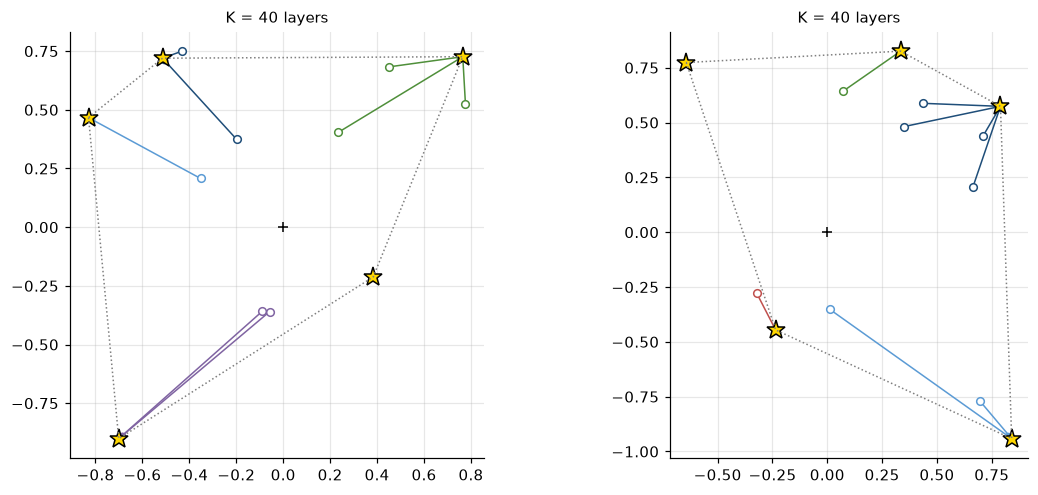

In [3]:
collections = [tokens_E7(streams["data"]) for _ in range(2)]
K_long = 4000


def clusters(Z, tol=1e-6):
    reps = []
    for z in Z:
        if not any(np.linalg.norm(z - r) < tol for r in reps):
            reps.append(z)
    return np.array(reps)


runs = []
for c, Z0 in enumerate(collections):
    dist = min(np.linalg.norm(Z0[i] - Z0[j]) for i in range(len(Z0)) for j in range(i))
    traj = hardmax_flow(Z0, A_E7, alpha_E7, K_long)
    L0 = leaders(Z0, A_E7)
    final = traj[-1]
    # Colouring rule for THESE draws only: every limit observed here is an initial leader (largest distance printed
    # below). It is not a general rule: a limit can be an emergent leader or a projection onto a face.
    follow = np.array([L0[np.argmin(np.linalg.norm(Z0[L0] - z, axis=1))] for z in final])
    runs.append({"Z0": Z0, "traj": traj, "leaders": L0, "follow": follow})
    print(f"collection {c + 1}: smallest |z_i| = {np.linalg.norm(Z0, axis=1).min():.3f}, smallest distance = {dist:.3f} "
          f"(nonzero, distinct); initial leaders (1-based): {[int(i) + 1 for i in L0]}")
    for K in (K_E7, 400, K_long):
        res = np.abs(traj[K] - traj[K - 1]).max()
        reps = clusters(traj[K])
        gap = np.abs(traj[K][:, None, :] - Z0[L0][None, :, :]).max(axis=2).min(axis=1).max()
        print(f"   K = {K:5d}: residual max|z^K - z^(K-1)| = {res:.1e},  clusters {len(reps):2d},  "
              f"largest distance of a token to the nearest initial leader {gap:.1e}")
    moved = np.abs(traj[:, L0] - Z0[L0]).max(axis=(1, 2))           # leaders' displacement (exact arithmetic: 0)
    print(f"   largest displacement of the initial leaders: {moved[K_E7]:.1e} after {K_E7} layers, {moved[-1]:.1e} after "
          f"{K_long};  all tokens inside the initial convex hull at every layer: "
          f"{bool(all(np.all(in_convex_hull(Z, Z0)) for Z in traj))}")

palette = [COLORS["state"], COLORS["control"], COLORS["adjoint"], COLORS["state2"], "#8064a2", "#f79646", "#4bacc6"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, run in zip(axes, runs):
    traj, L0 = run["traj"][:K_E7 + 1], run["leaders"]
    colour = {int(l): palette[k % len(palette)] for k, l in enumerate(L0)}
    for i in range(traj.shape[1]):
        ax.plot(traj[:, i, 0], traj[:, i, 1], "-", color=colour[int(run["follow"][i])], lw=1)
        ax.plot(*traj[0, i], "o", mfc="white", color=colour[int(run["follow"][i])], ms=5)
        ax.plot(*traj[-1, i], "o", color=colour[int(run["follow"][i])], ms=4)
    ax.plot(run["Z0"][L0, 0], run["Z0"][L0, 1], "*", color="black", ms=13, mfc="gold")
    hull = L0[convex_hull_2d(run["Z0"][L0])]
    ax.plot(*np.vstack([run["Z0"][hull], run["Z0"][hull[:1]]]).T, ":", color=COLORS["reference"], lw=1)
    ax.plot(0, 0, "+", color="black"); ax.set_aspect("equal"); ax.set_title(f"K = {K_E7} layers", fontsize=10)
plt.tight_layout(); plt.show()

**Figure 1.** E7: two collections of 13 tokens (open circles) after $K=40$ layers of the pure-attention hardmax transformer, $A=I$, $\alpha=0.1$ (filled circles: positions at layer 40). Stars are the leaders of the initial configuration, the dotted polygon their convex hull, and $+$ the origin. Each token is coloured by the leader it is closest to after 4000 layers.

*Interpretation (answer to the prediction).* Leaders do not move (Fact 2): their printed displacement after 40 layers is at the level of rounding, since $(z+0.1z)/1.1$ is not exactly $z$ in floating point. Every other token moves inside the convex hull (Fact 1, checked) towards a leader. In both collections, every token ends at an initial leader (printed distances at the level of $10^{-12}$), so the limit set observed consists of the five initial leaders of each collection; neither an emergent leader nor a projection onto a face appears in these two draws. The colouring by nearest initial leader is valid for these draws only; in general such limits would need categories of their own. After 40 layers the clusters are clearly forming, but they are not reached: the printed residual is about $10^{-3}$, and 13 distinct positions remain at the tolerance $10^{-6}$.

collection 1: clusters at K = 40, 100, 200, 400: [13, 13, 5, 5];  strict leaders drop below 5 at layer 250
collection 2: clusters at K = 40, 100, 200, 400: [13, 13, 5, 5];  strict leaders drop below 5 at layer 260


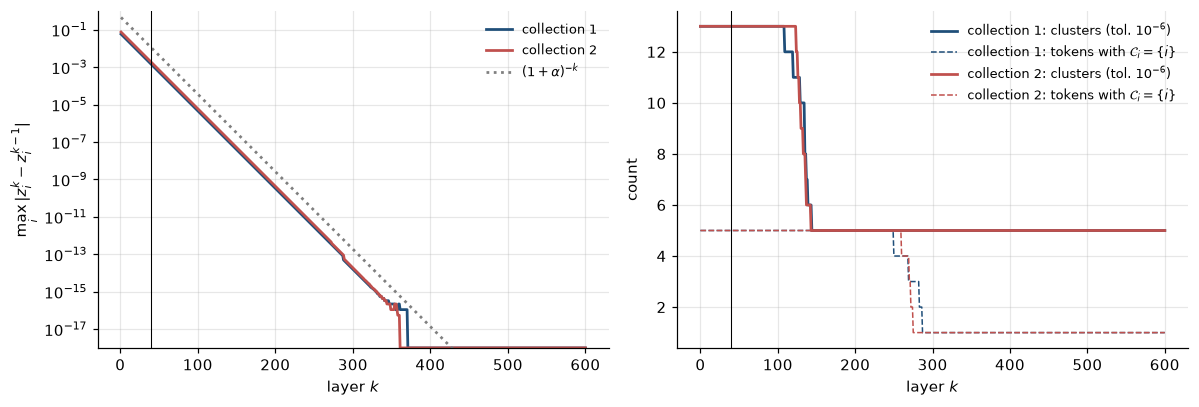

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for c, (run, col) in enumerate(zip(runs, (COLORS["state"], COLORS["control"]))):
    traj = run["traj"][:601]
    res = np.abs(np.diff(traj, axis=0)).max(axis=(1, 2))
    n_clusters = [len(clusters(Z)) for Z in traj]
    n_leaders = [len(leaders(Z, A_E7)) for Z in traj]
    ax1.semilogy(np.arange(1, len(res) + 1), np.maximum(res, 1e-18), color=col, label=f"collection {c + 1}")
    ax2.plot(n_clusters, color=col, label=f"collection {c + 1}: clusters (tol. $10^{{-6}}$)")
    ax2.plot(n_leaders, "--", color=col, lw=1, label=f"collection {c + 1}: tokens with $\\mathcal{{C}}_i=\\{{i\\}}$")
    first = int(np.argmax(np.array(n_leaders) < len(run["leaders"])))
    print(f"collection {c + 1}: clusters at K = 40, 100, 200, 400: {[n_clusters[k] for k in (40, 100, 200, 400)]};  "
          f"strict leaders drop below {len(run['leaders'])} at layer {first}")
k = np.arange(1, 601)
ax1.semilogy(k, 0.5 * 1.1 ** (-k.astype(float)), ":", color=COLORS["reference"], label=r"$(1+\alpha)^{-k}$")
ax1.axvline(K_E7, color="black", lw=0.7); ax1.set_ylim(1e-18, 1)
ax1.set_xlabel("layer $k$"); ax1.set_ylabel(r"$\max_i|z_i^{k}-z_i^{k-1}|$"); ax1.legend(fontsize=8.5)
ax2.axvline(K_E7, color="black", lw=0.7); ax2.set_xlabel("layer $k$"); ax2.set_ylabel("count"); ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Figure 2.** E7 over 600 layers. *Left:* the residual $\max_i|z_i^k-z_i^{k-1}|$ against the layer, with the rate $(1+\alpha)^{-k}$ of a follower attending to a fixed leader; the vertical line marks $K=40$. *Right:* the number of clusters (distance tolerance $10^{-6}$) and, dashed, the number of tokens that are strict leaders, $\mathcal C_i=\{i\}$.

*Interpretation.* After the last change of attended sets, the residual decays at the geometric rate $(1+\alpha)^{-k}$ computed in §3; the plot floors it at $10^{-18}$. The number of clusters drops to five, the number of leaders, between $K=100$ and $K=200$ (printed). The dashed curves and the printed displacements show artefacts of finite precision and of the tie tolerance fixed in advance, not of the mathematics. When a follower comes within the relative tolerance $10^{-12}$ of its leader, the two are treated as tied. The leader then no longer satisfies $\mathcal C_i=\{i\}$, and it moves by amounts of order $10^{-12}$ towards its follower: the printed displacement after 4000 layers. Soon after, rounding leaves every token unchanged: the residual becomes exactly $0$ with followers still about $10^{-12}$ from their leaders. In exact arithmetic followers never reach their leaders and leaders never move (§3). These are observations of finitely many layers in floating point; they illustrate the theorem, they do not prove it.

## 6. Control ↔ ML
`CORE`

- **Residual updates.** **MATHEMATICAL ANALOGY** with notebook 13. Attention and feed-forward blocks are residual steps, but the attention step depends on all tokens: it is the update of an interacting-particle system, not of $n$ independent copies of one system.
- **State-dependent averaging = consensus dynamics.** **MATHEMATICAL ANALOGY.** Each token moves towards an average of others chosen by the current configuration, as agents do in consensus and flocking models. Here the convex hull shrinks, leaders are fixed points, and clusters form.
- **Clustering and classification.** **FORWARD CONNECTION** with notebook 14 and the RESEARCH WINDOW. In the sentiment-analysis reading of p. 369, the encoder places relevant words as leaders, attention clusters the others around them, and a half-space readout, as in notebook 14, decides the label.

## 7. Common misconceptions
`CORE`

**"After the 40 layers of p. 366 the tokens have converged."** The theorem is asymptotic. After 40 layers with $\alpha=0.1$, a follower is still at about $2\%$ of its initial distance from its leader (§3, Figure 2).

**"The leader is the token of largest norm."** For $A=I$ the token of largest norm is a leader, but other tokens can be leaders too; E7 has five per collection (Exercise 1).

**"Ties have probability zero, so they do not matter."** Exact ties occur in symmetric configurations (§2), and after many layers every follower ties with its leader in floating point (Figure 2). The model's rule, averaging over *all* maximizers, decides what happens then.

**"Tokens can drift anywhere."** They never leave the convex hull of the initial tokens (Fact 1).

**"Softmax attention behaves like hardmax attention."** Only at low temperature, and only when the score gaps are not too small (DEEPER LOOK §8).

## 8. Softmax at low temperature, and ties
`DEEPER LOOK`

Practical transformers use **softmax** weights $\Lambda_{ij}=e^{\beta\langle Az_i,z_j\rangle}/\sum_\ell e^{\beta\langle Az_i,z_\ell\rangle}$, with an inverse temperature $\beta$. *(The comparison below is a pedagogical addition.)* As $\beta\to\infty$, the weights concentrate on the maximizers. If the largest score is attained at $q$ tokens and the next score is lower by a gap $g>0$, each maximizer receives weight $\frac1q+O(e^{-\beta g})$ and every other token $O(e^{-\beta g})$. **In the limit, the weights are uniform on all maximizers**, which is exactly the hardmax rule with ties of §2. A rule that chose one maximizer would not be the limit of softmax. The cell compares one softmax step with one hardmax step, for the tie configuration of §2 and for the first E7 collection, as $\beta$ grows.

tie configuration of section 2 (+ one token): smallest score gap 0.300;  deviation at beta = 1000: 5.0e-16
E7, collection 1: smallest score gap 0.005;  deviation at beta = 1000: 2.9e-04


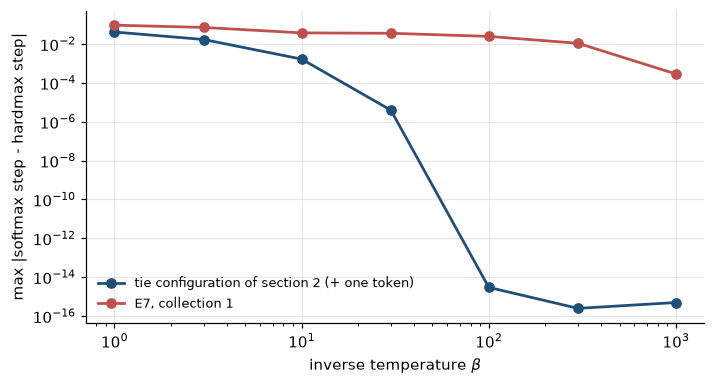

In [5]:
Z_tie = np.array([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5], [-0.4, 0.2]])
betas = np.array([1, 3, 10, 30, 100, 300, 1000])
fig, ax = plt.subplots(figsize=(6.6, 3.6))
for name, Z, col in (("tie configuration of section 2 (+ one token)", Z_tie, COLORS["state"]),
                     ("E7, collection 1", runs[0]["Z0"], COLORS["control"])):
    dev = [np.abs(softmax_step(Z, A_E7, alpha_E7, b) - hardmax_step(Z, A_E7, alpha_E7)).max() for b in betas]
    S = scores(Z, A_E7)
    srt = np.sort(S, axis=1)[:, ::-1]
    gaps = [row[0] - row[row < row[0] - 1e-12 * max(1, abs(row[0]))].max() for row in srt if np.any(row < row[0] - 1e-12)]
    print(f"{name}: smallest score gap {min(gaps):.3f};  deviation at beta = 1000: {dev[-1]:.1e}")
    ax.semilogy(betas, np.maximum(dev, 1e-17), "o-", color=col, label=name)
ax.set_xscale("log"); ax.set_xlabel(r"inverse temperature $\beta$"); ax.set_ylabel("max |softmax step - hardmax step|")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Figure 3.** One softmax attention step against one hardmax step ($A=I$, $\alpha=0.1$), as the inverse temperature $\beta$ grows, for a configuration with an exact three-way tie and for the first E7 collection.

*Interpretation.* The deviation decays like $e^{-\beta g}$, with $g$ the smallest gap between a row's maximum and its next score (printed). It is negligible once $\beta g$ is a few tens. With the tie, softmax converges to the average over the three tied tokens, the hardmax rule. A configuration with tiny gaps would need a very large $\beta$: softmax and hardmax dynamics can differ substantially over many layers.

## 9. Sentiment analysis and prompt engineering
`RESEARCH WINDOW`

The slides apply the model to a supervised task (pp. 368–369): classify IMDb movie reviews as positive or negative. A review of $n$ words, each a canonical basis vector of $\mathbb R^W$ ($W$ the vocabulary size), passes through three steps:
1. an **encoder** $Z^0=XE$ with a trainable $E\in\mathbb R^{W\times d}$;
2. the transformer $Z^K=\mathcal T_{A,\alpha}(Z^0)$;
3. a **decoder** $\hat y=\sigma\big(\frac1n\mathbf 1^\top Z^Kv+b\big)$, a logistic readout of the average token.

The slides fix $A=I$ and train $E$, $v$, $b$ and $\alpha$. They interpret the trained model as follows: *the encoder places relevant words (those conveying sentiment) as leaders; the transformer filters out irrelevant words by clustering them to the leaders; the decoder divides $\mathbb R^d$ into two half-spaces, one per sentiment* (p. 369).

**Prompt engineering** (pp. 370–371) changes a few words of a review classified as negative, e.g. "worst" → "best", "lamest" → "greatest", until it is classified as positive. Mathematically, the slides read this as *modifying words to change the clustering pattern*. These are interpretations of a trained model, reported in the slides with videos; we have not reproduced the experiment, and no data set is used here. The leader/follower picture of this notebook is what gives them a precise meaning.

## 10. What you should remember
`CORE`

1. Self-attention is a residual update in which each token moves towards a weighted average of the tokens; the weights depend on the whole configuration, so the tokens interact.
2. Hardmax attention averages over **all** maximizers of $\langle Az_i,z_j\rangle$; with $V=\alpha I$ and the normalization by $1+\alpha$, each step is a convex combination with step $\alpha/(1+\alpha)$.
3. Tokens stay in the convex hull of the initial tokens; leaders never move and stay leaders; a follower of a fixed leader approaches it at the rate $(1+\alpha)^{-k}$.
4. For nonzero, distinct tokens and $A$ symmetric positive definite, every token converges to a leader or to a projection of the origin onto a face of the leaders' polytope (p. 367). The theorem gives no rate.
5. Finite runs in floating point show the clustering, and also artefacts such as followers that become exactly equal to their leaders. They illustrate the theorem; they do not prove it.

## 11. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (who leads?)** · `FIRST PASS`. Take $A=I$. (a) Show that a token of largest norm, if unique, is a leader. (b) Give three tokens in $\mathbb R^2$ with two leaders, one of which does not have the largest norm. (c) Is a token in the interior of the convex hull of the others ever a leader?

**Exercise 2 ★★ (the normalization)** · `FIRST PASS`. (a) Starting from the layer of p. 365 with $V=\alpha I$, derive the update of p. 367 and its two forms. (b) What happens to a leader over $K$ layers *without* the division by $1+\alpha$? (c) Verify numerically on an E7 collection that the normalized layer coincides with `hardmax_step`.

**Exercise 3 ★★ (why nonzero and distinct?)** · `STANDARD`. (a) Show that the token $z_i=0$ attends to every token, and compute its next position. (b) Show that two identical tokens attend to the same set and remain identical forever. (c) Explain how each fact interferes with the statement "the leaders are the vertices of $\mathcal K$" of the theorem.

**Exercise 4 ★★ (a different attention matrix)** · `STANDARD`. Take $A=\mathrm{diag}(1,9)$ and the first E7 collection. (a) Compute the initial leaders and compare with $A=I$. (b) Run 400 layers and count the clusters. (c) Interpret: what does $A$ change in the geometry of "who attends to whom"?

**Exercise 5 ★★★ (planted leaders)** · `ADVANCED`. Design an initial configuration with three *planted* leaders, the points of radius $2$ at angles $90^\circ$, $210^\circ$ and $330^\circ$, and ten other tokens drawn from a small disc of radius $0.5$ around the origin, deterministically (for instance on a spiral). (a) Check that exactly the three planted tokens are leaders. (b) Predict, from the scores, which leader each of the ten tokens will follow, and verify after 400 layers. (c) Can you place an additional token so that it rests at the projection of the origin onto an edge of the triangle?

In [6]:
# TODO: student exercise (Exercise 5)
# Return a (13, 2) array: three planted leaders first, then ten tokens in the disc of radius 0.5.

def planted_tokens():
    ...  # your code here
    return None

**Exercise 6 ★★★ (how many layers?)** · `ADVANCED`. (a) Using the follower rate of §3, how many layers are needed for a follower to get within $10^{-6}$ of its leader from an initial distance $1$, for $\alpha=0.1$ and for $\alpha=1$? (b) Check the prediction for $\alpha=0.1$ on the residual curves of Figure 2, taking into account that a token may change its attended set before following a fixed leader. (c) Why can no statement of this kind be uniform over all configurations?

## Where are we going?
`CORE`

With many tokens, it is natural to stop following each one and to follow their **distribution** instead. [Notebook 16](16_neural_transport.ipynb) does this for neural ODEs: a flow transports a probability density, the control is chosen to transport one distribution to another, and the same fields learn dynamics from trajectory data.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Tokens and self-attention | 364 | Tokens; self-attention layer with weights $\Lambda^A_{ij}$; feed-forward layer |
| §2 Hardmax attention | 365, 367 | $\mathcal C_i(Z)$, leaders, $A$ symmetric positive definite, $V=\alpha I$; the pure-attention update |
| §3 Two facts | — | Pedagogical additions (proofs of the convex-hull and leader properties; follower rate) |
| §4 Clustering theorem | 366, 367 | Theorem (Alcalde–Fantuzzi–Zuazua); 13 tokens, $A=I$, $\alpha=0.1$, $K=40$ |
| §5 E7 laboratory | 366 | Experiment of p. 366 (our token law; longer horizons and residual metrics are additions) |
| §6 Control ↔ ML | 364, 369 | Residual structure; leaders, clustering and half-space decoder |
| §8 Softmax (DEEPER LOOK) | — | Pedagogical addition (low-temperature limit with ties) |
| §9 Sentiment analysis (RESEARCH WINDOW) | 368–371 | Encoder–transformer–decoder; interpretation; prompt engineering |

The source-map rows also record the pedagogical additions:
- the normalization by $1+\alpha$ derived;
- the hand step and the tie example;
- the two proofs and the follower rate;
- the E7 law and the horizons $K=400$, $4000$ (Figures 1–2);
- the softmax comparison (Figure 3).

They also record the remarks:
- the theorem's hypotheses (nonzero, distinct tokens; $A$ symmetric positive definite) are not needed for Facts 1–2;
- leaders lose the strict-maximum property in floating point once followers coincide with them.